In [12]:
# 1.importing libraries
import pandas as pd
# WHY: Core library for data manipulation and tabular operations

import numpy as np
# WHY: Used for numerical computations and simulation logic (vectorized operations)

import matplotlib.pyplot as plt
# WHY: Used for visualization of results

from scipy import stats
# WHY: Used for statistical testing (to validate simulation impact)

from sqlalchemy import create_engine
# WHY: Used to simulate real-world database storage instead of flat files

In [13]:
#2. Load Dataset
# Load Excel dataset
# WHY: Most business datasets are stored in Excel format
df = pd.read_excel(r"C:\Users\Kushitha\OneDrive\Desktop\Decision_Intelligence_Simulator\data_Online Retail.xlsx", engine="openpyxl")

# Preview dataset
# WHY: Quick sanity check to ensure data loaded correctly
print(df.head())

# Check structure
# WHY: Helps understand column types and missing values
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [14]:
#3.Data Understanding
# Check missing values
# WHY: Missing data affects accuracy of analysis
print(df.isnull().sum())

# Summary statistics
# WHY: Helps understand distribution of numerical features
print(df.describe())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.00000

In [15]:

# DATA CLEANING

# Remove rows where CustomerID is missing
# WHY: Cannot track customer behavior without ID
df.dropna(subset=['CustomerID'], inplace=True)

# Remove negative quantity (returns)
# WHY: These are returned/cancelled orders, not actual sales
df = df[df['Quantity'] > 0]

# Remove invalid prices
# WHY: Negative or zero prices distort revenue calculations
df = df[df['UnitPrice'] > 0]

# Reset index after cleaning
# WHY: Keeps dataframe clean and ordered
df.reset_index(drop=True, inplace=True)

In [16]:
#After cleaning
print(df.isnull().sum())
print(df.describe())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       179.331775                            NaN      22.097877   

          CustomerID  
count  397884.000000  
mean    15294.423453  
min     12346.000000  
25%     13969.000000  
50%     15159.000000  
75%     16795.000000  
max     18287.000000  
std      1713.141560  


In [17]:
# OUTLIER Handling
# Remove extreme Quantity values
# WHY: Very high values distort revenue calculations
df = df[df['Quantity'] < 10000]

# Remove extreme UnitPrice values
# WHY: Unrealistic prices affect simulation accuracy
df = df[df['UnitPrice'] < 1000]

In [18]:
print(df.describe())

            Quantity                    InvoiceDate      UnitPrice  \
count  397861.000000                         397861  397861.000000   
mean       12.598825  2011-07-10 23:40:31.667843328       2.989304   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max      4800.000000            2011-12-09 12:50:00     908.160000   
std        42.887052                            NaN       6.994535   

          CustomerID  
count  397861.000000  
mean    15294.491066  
min     12347.000000  
25%     13969.000000  
50%     15159.000000  
75%     16795.000000  
max     18287.000000  
std      1713.119374  


In [19]:
# Creating Revenue column
# WHY: Core metric for business decision making
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [20]:
# Store baseline revenue
# WHY: Needed to compare with simulated scenarios
original_revenue = df['Revenue'].sum()

print("Original Revenue:", original_revenue)

Original Revenue: 8615084.884


In [21]:
# Converting to datetime
# WHY: Enables time-based analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract month
# WHY: Used for trend analysis
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [22]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
397879,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
397880,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
397881,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
397882,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [23]:
df['CustomerTotalSpend'] = df.groupby('CustomerID')['Revenue'].transform('sum')

In [24]:
# Calculate total spend per customer
# WHY: Identifies high-value vs low-value customers based on their total contribution
df['CustomerTotalSpend'] = df.groupby('CustomerID')['Revenue'].transform('sum')

In [25]:
# Segment customers into categories based on spending
# WHY: Converts raw spending into meaningful business groups (Low, Medium, High value customers)
#      Useful for applying different strategies (e.g., pricing sensitivity)
df['CustomerSegment'] = pd.qcut(
    df['CustomerTotalSpend'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [26]:
# Calculate total revenue per invoice (order value)
# WHY: Helps analyze purchasing behavior and average order size
df['InvoiceTotal'] = df.groupby('InvoiceNo')['Revenue'].transform('sum')

In [27]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,CustomerTotalSpend,CustomerSegment,InvoiceTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,5391.21,High,139.12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,5391.21,High,139.12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,5391.21,High,139.12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,5391.21,High,139.12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,5391.21,High,139.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397879,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12,862.81,Low,249.45
397880,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12,862.81,Low,249.45
397881,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12,862.81,Low,249.45
397882,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12,862.81,Low,249.45


In [28]:
# Map elasticity values
# WHY: Different customer groups respond differently to price changes
elasticity_map = {
    'Low': -0.8,     # very sensitive
    'Medium': -0.5,  # moderate
    'High': -0.2     # less sensitive
}

In [29]:
def simulate_segmented_price_change(data, price_increase_pct):
    
    temp = data.copy()
    
    # Apply price increase
    temp['UnitPrice'] = temp['UnitPrice'] * (1 + price_increase_pct)
    
    # Apply segment-based elasticity
    temp['Elasticity'] = temp['CustomerSegment'].map(elasticity_map).astype(float)
    
    # Adjust quantity based on elasticity
    temp['Quantity'] = temp['Quantity'] * (1 + temp['Elasticity'] * price_increase_pct)
    
    # Prevent negative values
    temp['Quantity'] = np.maximum(temp['Quantity'], 0)
    
    # Add randomness
    noise = np.random.normal(0, 0.05, len(temp))
    temp['Quantity'] = temp['Quantity'] * (1 + noise)
    
    # Recalculate revenue
    temp['Revenue'] = temp['UnitPrice'] * temp['Quantity']
    
    return temp

In [39]:
stats.ttest_ind(df['Revenue'], sim_df['Revenue'])

TtestResult(statistic=np.float64(-7.972011211252975), pvalue=np.float64(1.563170553552069e-15), df=np.float64(795720.0))

In [30]:
scenarios = [0.05, 0.10, 0.15]

results = {}

for s in scenarios:
    sim_df = simulate_segmented_price_change(df, s)
    
    revenue = sim_df['Revenue'].sum()   # 👈 THIS LINE CALCULATES REVENUE
    
    results[s] = revenue
    
    print(f"{int(s*100)}% increase revenue:", revenue)


5% increase revenue: 8867575.131144557
10% increase revenue: 9101999.39629258
15% increase revenue: 9320332.107234735


In [31]:
for s, rev in results.items():
    change = ((rev - original_revenue) / original_revenue) * 100
    print(f"{int(s*100)}% → Revenue Change: {round(change,2)}%")

5% → Revenue Change: 2.93%
10% → Revenue Change: 5.65%
15% → Revenue Change: 8.19%


In [32]:
# Revenue contribution by segment
segment_revenue = df.groupby('CustomerSegment')['Revenue'].sum()

print(segment_revenue)

CustomerSegment
Low       1728236.033
Medium    2175168.991
High      4711679.860
Name: Revenue, dtype: float64


C:\Users\Kushitha\AppData\Local\Temp\ipykernel_11496\3881853694.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = df.groupby('CustomerSegment')['Revenue'].sum()


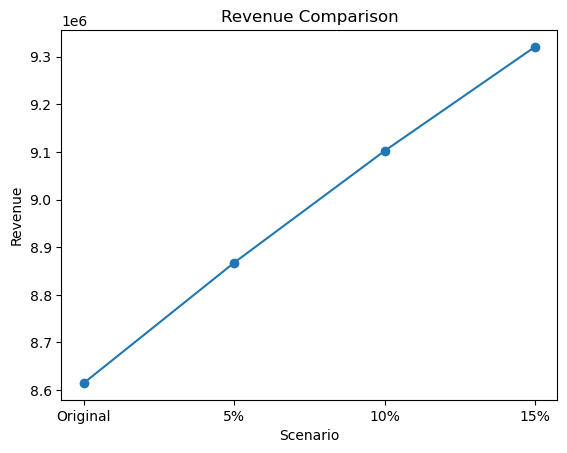

In [33]:
# Revenue Comparison
# Prepare labels and values
# WHY: Compare original revenue with simulated scenarios
labels = ['Original', '5%', '10%', '15%']
values = [original_revenue, results[0.05], results[0.10], results[0.15]]

# Plot line chart
# WHY: Line chart clearly shows trend across scenarios
plt.plot(labels, values, marker='o')

# Add titles and labels
# WHY: Makes graph understandable
plt.title("Revenue Comparison")
plt.xlabel("Scenario")
plt.ylabel("Revenue")
plt.show()

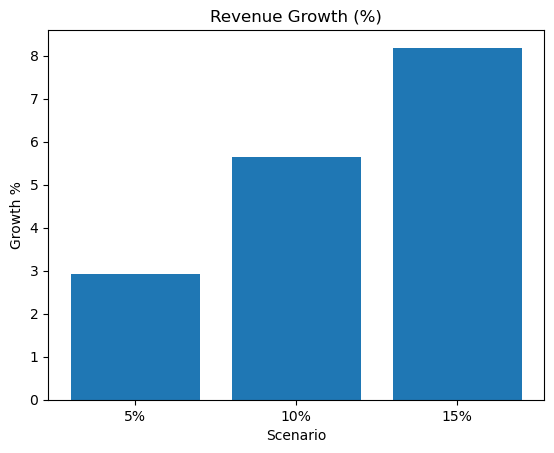

In [34]:
# Revenue Growth %
# Calculate growth percentage
# WHY: Shows business impact in percentage form (more meaningful than raw values)
growth = [
    ((results[0.05] - original_revenue) / original_revenue) * 100,
    ((results[0.10] - original_revenue) / original_revenue) * 100,
    ((results[0.15] - original_revenue) / original_revenue) * 100
]

plt.bar(['5%', '10%', '15%'], growth)

plt.title("Revenue Growth (%)")
plt.xlabel("Scenario")
plt.ylabel("Growth %")

plt.show()

C:\Users\Kushitha\AppData\Local\Temp\ipykernel_11496\3466990409.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = df.groupby('CustomerSegment')['Revenue'].sum()


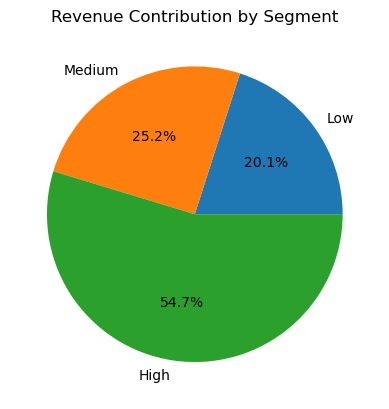

In [35]:
# Simple Customer Segment Revenue
segment_revenue = df.groupby('CustomerSegment')['Revenue'].sum()

plt.pie(segment_revenue, 
        labels=segment_revenue.index, 
        autopct='%1.1f%%')

plt.title("Revenue Contribution by Segment")

plt.show()

In [36]:


results_df = pd.DataFrame({
    'Scenario': ['5%', '10%', '15%'],
    'Revenue': [results[0.05], results[0.10], results[0.15]]
})

results_df.to_excel(r"C:\Users\Kushitha\OneDrive\Desktop\Decision_Intelligence_Simulator\results.xlsx", index=False)

In [37]:
from sqlalchemy import create_engine

# Create a SQLite engine (database will be created if it doesn't exist)
# WHY: Stores results in a structured format for further queries or BI tools
engine = create_engine('sqlite:///DecisionIntelligenceSimulator.db')

In [38]:
# Store results in a table called 'revenue_simulation'
# WHY: Allows easy retrieval, integration with other systems, or historical analysis
results_df.to_sql('revenue_simulation', con=engine, if_exists='replace', index=False)

3